# Reparameterized Variational Inference (JAX)

## Real-World Scenario: Inferring mRNA Kinetic Parameters from RNA-seq Counts

**From PML-2 Chapter 10.2**

This is a JAX port of `10-2-1-reparameterized_vi.ipynb`. Same scenario, same math, same plots — the variational families are written as functional pytrees with `optax` for Adam and `jax.jit` for the training step.

In whole-cell modeling, every gene has two kinetic parameters that govern its mRNA pool:
- $k_{\text{syn}}$ — transcription rate (mRNAs produced per unit time)
- $k_{\text{deg}}$ — degradation rate (fraction of pool degraded per unit time)

At steady state, the mean mRNA copy number is the ratio $\lambda = k_{\text{syn}} / k_{\text{deg}}$.

RNA-seq gives us **noisy count observations** of that steady-state pool, modeled as Poisson. The catch: the data only constrains the **ratio**, not the individual rates. That makes the joint posterior $p(\log k_{\text{syn}}, \log k_{\text{deg}} \mid \text{data})$ highly correlated along the diagonal — a classic banana-shape that exposes the weakness of mean-field variational inference.

We use this as a testbed to compare three Gaussian variational families described in Section 10.2.1:

1. **Diagonal covariance** (mean field) — Section 10.2.1.1
2. **Full covariance** via Cholesky — Section 10.2.1.2
3. **Low-rank + diagonal** (factor) covariance — Section 10.2.1.3

All three are trained via the **reparameterization trick**: gradients flow through stochastic samples by writing $z = g(\boldsymbol{\phi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from typing import NamedTuple
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jstats
import jax.scipy.linalg as jlinalg
import optax

key = jr.PRNGKey(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 Chapter 10.2

### The ELBO (Eq. 10.9 / 10.11)
$$\mathcal{L}_{\text{ELBO}}(\boldsymbol{\psi}) \;=\; \mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}\!\left[\log p(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})\right] \;\le\; \log p(\mathbf{x})$$

Maximizing the ELBO is equivalent to minimizing $D_{\mathrm{KL}}\!\left(q_{\boldsymbol{\psi}}(\mathbf{z}) \,\|\, p(\mathbf{z}\mid\mathbf{x})\right)$. The book writes ELBO as the Polish-L glyph Ł — we use $\mathcal{L}_{\text{ELBO}}$ here so the math renders in standard LaTeX.

### Reparameterization (Eq. 10.36 / 10.40)
Rewrite $\mathbf{z} \sim q_{\boldsymbol{\psi}}(\mathbf{z})$ as $\mathbf{z} = g(\boldsymbol{\psi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim p(\boldsymbol{\epsilon})$ free of $\boldsymbol{\psi}$:
$$\nabla_{\boldsymbol{\psi}}\,\mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}[f(\mathbf{z})] \;=\; \mathbb{E}_{p(\boldsymbol{\epsilon})}\!\left[\nabla_{\boldsymbol{\psi}}\, f\!\left(g(\boldsymbol{\psi}, \boldsymbol{\epsilon})\right)\right]$$

### Three Gaussian families
| Family | Reparameterization | Parameters |
|---|---|---|
| Diagonal (Eq. 10.44) | $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ | $2d$ |
| Full (Eq. 10.52) | $\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}$, $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ | $d + d(d{+}1)/2$ |
| Low-rank + diag (Eq. 10.57) | $\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2)$ | $3d$ |

### Functional JAX style
In place of PyTorch `nn.Module` subclasses, each variational family is represented by:
- a `NamedTuple` of parameters (a pytree, so `jax.grad` and `optax` traverse it automatically),
- a pure `sample(params, key, S) -> (z, log_q)` function used by the trainer,
- a pure `covariance(params)` function used for reporting.

This is the idiomatic JAX equivalent of holding learnable state inside `nn.Parameter` fields.

## Step 1: The Generative Model

The generative model is a small story for how the observed RNA counts could have been produced. For one gene, imagine an unobserved mRNA birth-death process:
- mRNAs are synthesized at rate $k_{\text{syn}}$
- each existing mRNA molecule degrades independently at rate $k_{\text{deg}}$
- at steady state, the expected mRNA copy number is
  $$\lambda = \frac{k_{\text{syn}}}{k_{\text{deg}}}$$

We parameterize on the log-scale so the rates stay positive:
- $\theta_1 = \log k_{\text{syn}}$, $\theta_2 = \log k_{\text{deg}}$
- Prior: $\theta_1, \theta_2 \sim \mathcal{N}(0, 1)$ (weakly informative)
- Steady-state mean: $\lambda = \exp(\theta_1 - \theta_2)$
- Likelihood (RNA-seq replicates): $y_n \sim \mathrm{Poisson}\!\left(\lambda\right)$, for $n = 1, \dots, N$

Why Poisson? The observations are **counts**, so they must be nonnegative integers. The Poisson distribution is the simplest model for independent count events around an average rate $\lambda$. It also matches the simple birth-death intuition: when mRNAs are produced at a constant rate and degraded independently, the steady-state copy number is Poisson with mean $k_{\text{syn}}/k_{\text{deg}}$.

So the model is
$$\theta_1, \theta_2 \sim \mathcal{N}(0, 1), \qquad \lambda = e^{\theta_1 - \theta_2}, \qquad y_n \sim \mathrm{Poisson}(\lambda).$$

The joint log-density is
$$\log p(\boldsymbol{\theta}, \mathbf{y}) = \log p(\boldsymbol{\theta}) + \sum_n y_n (\theta_1 - \theta_2) - N\,e^{\theta_1 - \theta_2} + \text{const}.$$

Because the likelihood depends only on $\theta_1 - \theta_2$, the data constrains the **ratio** $k_{\text{syn}}/k_{\text{deg}}$, not the two rates separately. If both rates move together, the ratio can stay almost unchanged. That is why the posterior forms a narrow diagonal band shrunk toward the origin by the prior.

In real RNA-seq, a Poisson likelihood is often too simple because counts can be overdispersed; a negative binomial likelihood is commonly more realistic. Here Poisson keeps the example focused on the variational inference issue: the posterior is strongly correlated because the likelihood depends on $\theta_1 - \theta_2$.

### Why we need the joint log-density

Look at the ELBO from the top of the notebook:
$$\mathcal{L}_{\text{ELBO}}(\boldsymbol{\psi}) = \mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}\!\left[\log p(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})\right].$$

To take a gradient step, the trainer needs to evaluate **both terms inside the brackets** at sampled $\mathbf{z}$:
- $\log q_{\boldsymbol{\psi}}(\mathbf{z})$ — easy, we chose $q$ (Gaussian).
- $\log p(\mathbf{x}, \mathbf{z})$ — the joint log-density of the model. **That's the thing we derive next.**

We *can't* use the true posterior $\log p(\mathbf{z} \mid \mathbf{x})$ instead, because that needs the intractable marginal $\log p(\mathbf{x}) = \log \int p(\mathbf{x}, \mathbf{z})\, d\mathbf{z}$ — the whole reason we're doing VI in the first place. But the **joint** factors cleanly as $p(\boldsymbol{\theta})\,p(\mathbf{y}\mid\boldsymbol{\theta})$ — prior times likelihood — both of which we wrote down in the generative model above, so it's directly computable.

So the chain is: **generative story → joint log-density → ELBO → gradient step on $\boldsymbol{\psi}$.** The `log_joint_jax` function in Step 3 is exactly this formula, and `train_vi` plugs it straight into `elbo = (log_p - log_q).mean()`.

### Where the joint log-density comes from

It's just $\log p(\boldsymbol{\theta}, \mathbf{y}) = \log p(\boldsymbol{\theta}) + \log p(\mathbf{y} \mid \boldsymbol{\theta})$, with the Poisson likelihood written out.

**Prior part.** Two independent $\mathcal{N}(0,1)$ priors give
$$\log p(\boldsymbol{\theta}) = -\tfrac{1}{2}(\theta_1^2 + \theta_2^2) + \text{const}.$$

**Likelihood part.** For one count, $p(y_n \mid \lambda) = \lambda^{y_n} e^{-\lambda} / y_n!$, so
$$\log p(y_n \mid \lambda) = y_n \log \lambda - \lambda - \log(y_n!).$$

Summing over the $N$ independent replicates:
$$\log p(\mathbf{y} \mid \lambda) = \Big(\sum_n y_n\Big)\log \lambda - N\lambda - \sum_n \log(y_n!).$$

**Substitute** $\lambda = e^{\theta_1 - \theta_2}$, so $\log \lambda = \theta_1 - \theta_2$:
$$\log p(\mathbf{y} \mid \boldsymbol{\theta}) = \Big(\sum_n y_n\Big)(\theta_1 - \theta_2) - N\, e^{\theta_1 - \theta_2} + \text{const}.$$

The $+\,\text{const}$ absorbs $-\sum_n \log(y_n!)$, which depends only on the data, not on $\boldsymbol{\theta}$ — so it drops out for inference (it shifts the ELBO by a constant but doesn't affect the gradient or the optimum). Adding the two pieces gives the line above, and it's mirrored directly in the `log_joint` function below.

In [2]:
# --- Ground-truth kinetic parameters for one gene ---
k_syn_true = 8.0    # mRNAs per unit time
k_deg_true = 2.0    # fraction per unit time -> steady-state lambda = 4 copies
lambda_true = k_syn_true / k_deg_true

theta_true = np.array([np.log(k_syn_true), np.log(k_deg_true)])
print(f"True (log k_syn, log k_deg) = ({theta_true[0]:.3f}, {theta_true[1]:.3f})")
print(f"Steady-state lambda = {lambda_true:.2f} mRNA copies")

# --- Simulate RNA-seq replicate counts ---
N = 30  # number of replicate count measurements
y_obs = np.random.poisson(lam=lambda_true, size=N)
print(f"\nObserved counts (first 10 of {N}): {y_obs[:10]}")
print(f"Sample mean: {y_obs.mean():.2f} (true lambda = {lambda_true:.2f})")

# Move to JAX arrays. y_sum and N_j are scalars used inside the ELBO.
y_j = jnp.asarray(y_obs, dtype=jnp.float32)
y_sum = y_j.sum()
N_j = jnp.float32(N)

True (log k_syn, log k_deg) = (2.079, 0.693)
Steady-state lambda = 4.00 mRNA copies

Observed counts (first 10 of 30): [6 7 1 8 4 3 7 3 2 4]
Sample mean: 4.03 (true lambda = 4.00)


## Step 2: The Exact Posterior (via Grid Evaluation)

Before evaluating the posterior on a grid, recall Bayes' rule:
$$p(\boldsymbol{\theta}\mid\mathbf{y}) = \frac{p(\boldsymbol{\theta})p(\mathbf{y}\mid\boldsymbol{\theta})}{p(\mathbf{y})} = \frac{p(\boldsymbol{\theta},\mathbf{y})}{p(\mathbf{y})} \propto p(\boldsymbol{\theta},\mathbf{y}).$$

For this model, the posterior density is
$$p(\theta_1,\theta_2\mid\mathbf{y}) \propto \exp\left[-\frac{1}{2}(\theta_1^2+\theta_2^2) + \left(\sum_n y_n\right)(\theta_1-\theta_2) - N e^{\theta_1-\theta_2}\right].$$

So the `log_joint` function below is really the **unnormalized log posterior**:
$$\log p(\boldsymbol{\theta},\mathbf{y}) = \log p(\boldsymbol{\theta}) + \log p(\mathbf{y}\mid\boldsymbol{\theta}).$$

We use the joint density because the missing denominator $p(\mathbf{y})$ is the marginal likelihood. It normalizes the posterior, but it does not depend on $\boldsymbol{\theta}$, so it only rescales the surface. For plotting the posterior shape on a grid, we can evaluate the unnormalized log posterior at every grid point.

We work in log-space for numerical stability: products of many probabilities become sums of log probabilities. The code subtracts `log_post.max()` before exponentiating so the largest grid value is 1, which avoids overflow or severe underflow.

After exponentiating, `post` is still only proportional to the posterior. To turn it into a proper 2D density, we normalize it so its integral over the grid is approximately 1:
$$\int\!\int p(\theta_1,\theta_2\mid\mathbf{y})\,d\theta_1\,d\theta_2 \approx \sum_{i,j} p_{ij}\,\Delta\theta_1\,\Delta\theta_2 = 1.$$

That is why the normalization divides by `post.sum() * (t1_grid[1] - t1_grid[0]) * (t2_grid[1] - t2_grid[0])`. The `post.sum()` term adds the density heights, and the two grid spacings multiply each height by its small grid-cell area.

The posterior is 2D and unimodal, so we can compute it on a fine grid as ground truth. This is what each variational approximation should ideally match.

In [3]:
def log_joint(theta1, theta2, y_sum_val, N_val):
    """Unnormalized log p(theta, y) up to a constant in y. NumPy version for grid eval."""
    log_prior = -0.5 * (theta1**2 + theta2**2)        # N(0,1) priors, dropped constants
    log_lik = y_sum_val * (theta1 - theta2) - N_val * np.exp(theta1 - theta2)
    return log_prior + log_lik

# Fine grid for visualization
t1_grid = np.linspace(-2.5, 4.0, 250)
t2_grid = np.linspace(-3.5, 3.0, 250)
T1, T2 = np.meshgrid(t1_grid, t2_grid)

log_post = log_joint(T1, T2, y_obs.sum(), N)
log_post -= log_post.max()       # numerical stability before exponentiating
post = np.exp(log_post)

# Normalize the 2D density: sum of heights times grid-cell area should equal 1.
dx = (t1_grid[1] - t1_grid[0]) * (t2_grid[1] - t2_grid[0])
post /= post.sum() * dx

# Posterior moments by numerical integration
mu1_exact = (T1 * post).sum() * dx
mu2_exact = (T2 * post).sum() * dx
var1_exact = ((T1 - mu1_exact)**2 * post).sum() * dx
var2_exact = ((T2 - mu2_exact)**2 * post).sum() * dx
cov_exact = ((T1 - mu1_exact) * (T2 - mu2_exact) * post).sum() * dx
corr_exact = cov_exact / np.sqrt(var1_exact * var2_exact)

print(f"Exact posterior moments:")
print(f"  E[theta1] = {mu1_exact:.3f}, sd = {np.sqrt(var1_exact):.3f}")
print(f"  E[theta2] = {mu2_exact:.3f}, sd = {np.sqrt(var2_exact):.3f}")
print(f"  corr(theta1, theta2) = {corr_exact:.3f}")
print(f"  E[theta1 - theta2] = {mu1_exact - mu2_exact:.3f} (true log lambda = {np.log(lambda_true):.3f})")

Exact posterior moments:
  E[theta1] = 0.692, sd = 0.708
  E[theta2] = -0.692, sd = 0.708
  corr(theta1, theta2) = 0.992
  E[theta1 - theta2] = 1.385 (true log lambda = 1.386)


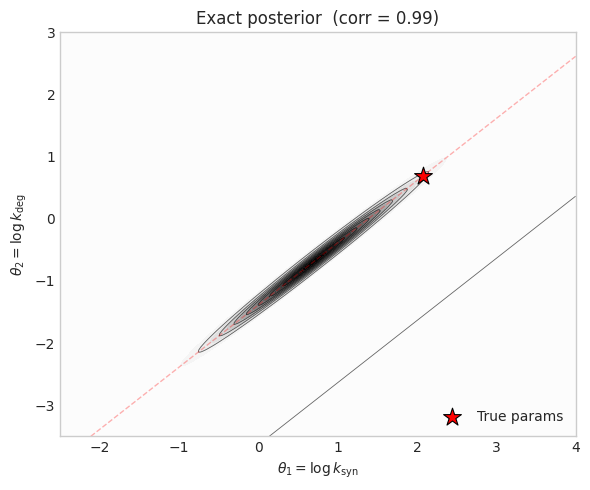

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=8, colors='black', linewidths=0.6, alpha=0.6)
ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*', s=180,
           edgecolor='black', linewidth=0.8, zorder=5, label='True params')
ax.axline((0, np.log(lambda_true) * -1 + 0), slope=1, color='red', alpha=0.3,
          linestyle='--', linewidth=1)
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title(f'Exact posterior  (corr = {corr_exact:.2f})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

The posterior is a tight diagonal ridge — knowing $\theta_1 - \theta_2$ (the log steady-state level) doesn't tell us the rates individually. A Gaussian variational family that **ignores the off-diagonal correlation** will be a poor fit; one that captures it should match the ridge closely.

## Step 3: A Generic Reparameterized VI Trainer (JAX style)

All three Gaussian families share the same training loop:
1. Draw $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ from a fresh PRNG key.
2. Form $\mathbf{z} = g(\boldsymbol{\psi}, \boldsymbol{\epsilon})$ and compute $\log q_{\boldsymbol{\psi}}(\mathbf{z})$.
3. Evaluate $\log p(\mathbf{z}, \mathbf{y}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})$.
4. Take an Adam step on the **negative** ELBO.

The pattern is:
- Each variational family is a `(params, sample_fn)` pair, where `sample_fn(params, key, S) -> (z, log_q)`.
- `train_vi` builds a `loss_fn(params, key)` closure, JITs the gradient step via `jax.value_and_grad`, and walks the optimizer with `optax`.
- We split the master PRNG key each step so different iterations see different noise — JAX's PRNGs are explicit, unlike PyTorch's implicit global generator.

In [5]:
def log_joint_jax(theta, y_sum, N):
    """theta: (S, 2) array of (theta1, theta2) samples. Returns (S,) log p(theta, y)."""
    t1, t2 = theta[..., 0], theta[..., 1]
    log_prior = -0.5 * (t1**2 + t2**2)
    log_lik = y_sum * (t1 - t2) - N * jnp.exp(t1 - t2)
    return log_prior + log_lik


def train_vi(params, sample_fn, key, num_steps=2000, num_samples=64, lr=1e-2, log_every=200):
    """Maximize the ELBO with Adam. Returns (final params, ELBO trace)."""
    opt = optax.adam(lr)
    opt_state = opt.init(params)

    def neg_elbo(params, k):
        z, log_q = sample_fn(params, k, num_samples)
        log_p = log_joint_jax(z, y_sum, N_j)
        elbo = (log_p - log_q).mean()
        return -elbo

    @jax.jit
    def step(params, opt_state, k):
        loss, grads = jax.value_and_grad(neg_elbo)(params, k)
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, -loss        # return ELBO for logging

    elbo_trace = []
    for s in range(num_steps):
        key, sub = jr.split(key)
        params, opt_state, elbo = step(params, opt_state, sub)
        elbo_trace.append(float(elbo))
        if (s + 1) % log_every == 0:
            print(f"  step {s+1:>4d}  ELBO = {float(elbo):.3f}")
    return params, elbo_trace

## Step 4: Diagonal Gaussian (Mean Field) — Eq. 10.43–10.44

$$\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$$

We store $\log\boldsymbol{\sigma}$ for unconstrained optimization. The log-density of $\mathbf{z}$ is the sum of independent Gaussians.

In [6]:
class DiagParams(NamedTuple):
    mu: jax.Array
    log_sigma: jax.Array


def diag_init(dim: int = 2) -> DiagParams:
    return DiagParams(mu=jnp.zeros(dim), log_sigma=jnp.zeros(dim))   # sigma = 1 at init


def diag_sample(params: DiagParams, key, S: int):
    sigma = jnp.exp(params.log_sigma)
    eps = jr.normal(key, (S, params.mu.shape[0]))
    z = params.mu + sigma * eps                                       # (S, d)
    log_q = jstats.norm.logpdf(z, params.mu, sigma).sum(-1)            # independent Gaussians
    return z, log_q


def diag_covariance(params: DiagParams):
    sigma = jnp.exp(params.log_sigma)
    return jnp.diag(sigma**2)


print("Training diagonal (mean-field) VI ...")
key, sub = jr.split(key)
params_diag = diag_init(dim=2)
params_diag, trace_diag = train_vi(params_diag, diag_sample, sub, num_steps=2000)

mu_diag = np.asarray(params_diag.mu)
Sigma_diag = np.asarray(diag_covariance(params_diag))
print(f"\nFitted q: mu = {mu_diag},  sigma = {np.sqrt(np.diag(Sigma_diag))}")
print(f"Covariance:\n{Sigma_diag}")

Training diagonal (mean-field) VI ...


  step  200  ELBO = 30.545
  step  400  ELBO = 42.068
  step  600  ELBO = 43.365
  step  800  ELBO = 43.870
  step 1000  ELBO = 43.900
  step 1200  ELBO = 44.024
  step 1400  ELBO = 44.350
  step 1600  ELBO = 43.961
  step 1800  ELBO = 44.085


  step 2000  ELBO = 44.236

Fitted q: mu = [ 0.69064385 -0.6905181 ],  sigma = [0.09318096 0.09295452]
Covariance:
[[0.00868269 0.        ]
 [0.         0.00864054]]


## Step 5: Full Covariance Gaussian — Eq. 10.51–10.55

We parameterize $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ with $\mathbf{L}$ lower triangular (positive diagonal), so
$$\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}.$$

We store the strictly lower-triangular entries and the log-diagonal separately, then assemble $\mathbf{L}$ on the fly. The log-density uses the Cholesky factor directly — a triangular solve plus the log-determinant $2\sum_i \log L_{ii}$ — instead of going through `multivariate_normal.logpdf`, which would re-factorize $\boldsymbol{\Sigma}$ internally.

In [7]:
class FullParams(NamedTuple):
    mu: jax.Array
    L_offdiag: jax.Array      # full (dim, dim) tensor; only strict-lower part used
    log_diag: jax.Array


def full_init(dim: int = 2) -> FullParams:
    return FullParams(
        mu=jnp.zeros(dim),
        L_offdiag=jnp.zeros((dim, dim)),
        log_diag=jnp.zeros(dim),
    )


def full_cholesky(params: FullParams):
    dim = params.mu.shape[0]
    mask = jnp.tril(jnp.ones((dim, dim)), k=-1)
    return mask * params.L_offdiag + jnp.diag(jnp.exp(params.log_diag))


def _mvn_logpdf_from_chol(z, mu, L):
    """log N(z; mu, L L^T) for batched z of shape (S, d)."""
    diff = z - mu                                              # (S, d)
    # Solve L u^T = diff^T columnwise; u has the whitened residuals.
    u = jlinalg.solve_triangular(L, diff.T, lower=True).T       # (S, d)
    quad = (u**2).sum(-1)
    log_det = 2.0 * jnp.log(jnp.diag(L)).sum()
    d = mu.shape[0]
    return -0.5 * (quad + log_det + d * jnp.log(2 * jnp.pi))


def full_sample(params: FullParams, key, S: int):
    L = full_cholesky(params)
    eps = jr.normal(key, (S, params.mu.shape[0]))
    z = params.mu + eps @ L.T                                   # (S, d)
    log_q = _mvn_logpdf_from_chol(z, params.mu, L)
    return z, log_q


def full_covariance(params: FullParams):
    L = full_cholesky(params)
    return L @ L.T


print("Training full-covariance VI ...")
key, sub = jr.split(key)
params_full = full_init(dim=2)
params_full, trace_full = train_vi(params_full, full_sample, sub, num_steps=2000)

mu_full = np.asarray(params_full.mu)
Sigma_full = np.asarray(full_covariance(params_full))
corr_full = Sigma_full[0, 1] / np.sqrt(Sigma_full[0, 0] * Sigma_full[1, 1])
print(f"\nFitted q: mu = {mu_full}")
print(f"Covariance:\n{Sigma_full}")
print(f"Implied correlation: {corr_full:.3f}  (exact: {corr_exact:.3f})")

Training full-covariance VI ...


  step  200  ELBO = 43.415
  step  400  ELBO = 45.460
  step  600  ELBO = 46.098
  step  800  ELBO = 46.137
  step 1000  ELBO = 46.307
  step 1200  ELBO = 46.364
  step 1400  ELBO = 46.292
  step 1600  ELBO = 46.331


  step 1800  ELBO = 46.355
  step 2000  ELBO = 46.368

Fitted q: mu = [ 0.69378066 -0.6882661 ]
Covariance:
[[0.49140197 0.4957508 ]
 [0.4957508  0.50881875]]
Implied correlation: 0.991  (exact: 0.992)


## Step 6: Low-Rank + Diagonal Gaussian (Factor) — Eq. 10.57

For high-dimensional latent spaces, full covariance has $O(d^2)$ parameters. A cheap middle ground is the rank-$r$ plus diagonal decomposition
$$\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2),$$
with only $(r+1)\,d$ extra parameters (plus $d$ for $\boldsymbol{\mu}$). For our 2D problem with $r{=}1$ this is also a full-covariance family — we use it to verify it recovers the same posterior.

The reparameterization uses two independent noise vectors: $\mathbf{z} = \boldsymbol{\mu} + \mathbf{b}\,\boldsymbol{\epsilon}_r + \mathbf{c} \odot \boldsymbol{\epsilon}_d$.

For the $\log q$ computation we use the **matrix-determinant lemma** and **Woodbury identity** so the cost scales as $O(d r^2)$ instead of $O(d^3)$:
$$\log|\boldsymbol{\Sigma}| = \log|\mathbf{I}_r + \mathbf{b}^\top D^{-1} \mathbf{b}| + \sum_i \log c_i^2, \qquad \boldsymbol{\Sigma}^{-1} = D^{-1} - D^{-1}\mathbf{b}\,(\mathbf{I}_r + \mathbf{b}^\top D^{-1}\mathbf{b})^{-1}\mathbf{b}^\top D^{-1},$$
with $D = \mathrm{diag}(\mathbf{c}^2)$. PyTorch's `LowRankMultivariateNormal` does the same trick internally; here we make it explicit.

In [8]:
class LowRankParams(NamedTuple):
    mu: jax.Array
    b: jax.Array         # (dim, rank)
    log_c: jax.Array     # (dim,)


def lr_init(dim: int, rank: int, key) -> LowRankParams:
    return LowRankParams(
        mu=jnp.zeros(dim),
        b=0.1 * jr.normal(key, (dim, rank)),
        log_c=jnp.zeros(dim),
    )


def lr_covariance(params: LowRankParams):
    c = jnp.exp(params.log_c)
    return params.b @ params.b.T + jnp.diag(c**2)


def _lowrank_logpdf(z, mu, b, c):
    """log N(z; mu, b b^T + diag(c^2)) via Woodbury + matrix-determinant lemma."""
    d, r = b.shape
    diff = z - mu                                              # (S, d)
    c2 = c**2
    bD = b / c2[:, None]                                       # D^{-1} b, shape (d, r)
    M = jnp.eye(r) + b.T @ bD                                  # I_r + b^T D^{-1} b, shape (r, r)
    L_M = jnp.linalg.cholesky(M)
    log_det = 2.0 * jnp.log(jnp.diag(L_M)).sum() + jnp.log(c2).sum()
    # quadratic form: diff^T Sigma^{-1} diff
    a = diff / c2                                              # D^{-1} diff, (S, d)
    bDdiff = diff @ bD                                         # (S, r)  ==  diff^T D^{-1} b
    # Sigma^{-1} diff = D^{-1} diff - D^{-1} b M^{-1} (b^T D^{-1} diff)
    sol = jlinalg.cho_solve((L_M, True), bDdiff.T).T            # (S, r)
    quad = (diff * a).sum(-1) - (bDdiff * sol).sum(-1)
    return -0.5 * (quad + log_det + d * jnp.log(2 * jnp.pi))


def lr_sample(params: LowRankParams, key, S: int):
    d, r = params.b.shape
    c = jnp.exp(params.log_c)
    k1, k2 = jr.split(key)
    eps_r = jr.normal(k1, (S, r))
    eps_d = jr.normal(k2, (S, d))
    z = params.mu + eps_r @ params.b.T + c * eps_d
    log_q = _lowrank_logpdf(z, params.mu, params.b, c)
    return z, log_q


print("Training low-rank (rank=1) + diagonal VI ...")
key, sub_init, sub_train = jr.split(key, 3)
params_lr = lr_init(dim=2, rank=1, key=sub_init)
params_lr, trace_lr = train_vi(params_lr, lr_sample, sub_train, num_steps=2000)

mu_lr = np.asarray(params_lr.mu)
Sigma_lr = np.asarray(lr_covariance(params_lr))
corr_lr = Sigma_lr[0, 1] / np.sqrt(Sigma_lr[0, 0] * Sigma_lr[1, 1])
print(f"\nFitted q: mu = {mu_lr}")
print(f"Covariance:\n{Sigma_lr}")
print(f"Implied correlation: {corr_lr:.3f}  (exact: {corr_exact:.3f})")

Training low-rank (rank=1) + diagonal VI ...


  step  200  ELBO = 37.565
  step  400  ELBO = 40.202
  step  600  ELBO = 44.291
  step  800  ELBO = 45.361
  step 1000  ELBO = 45.855
  step 1200  ELBO = 45.997
  step 1400  ELBO = 46.121
  step 1600  ELBO = 46.237


  step 1800  ELBO = 46.299
  step 2000  ELBO = 46.373

Fitted q: mu = [ 0.69529986 -0.6973618 ]
Covariance:
[[0.4903666 0.4927346]
 [0.4927346 0.5065542]]
Implied correlation: 0.989  (exact: 0.992)


## Step 7: Side-by-Side Comparison (mirrors Figure 10.2)

We overlay the three Gaussian approximations on top of the exact posterior. The mean-field axis-aligned ellipse will be **clearly over-confident** in the direction transverse to the ridge — a textbook example of why the mode-seeking KL$(q \| p)$ makes diagonal Gaussians collapse onto a single dimension of the posterior.

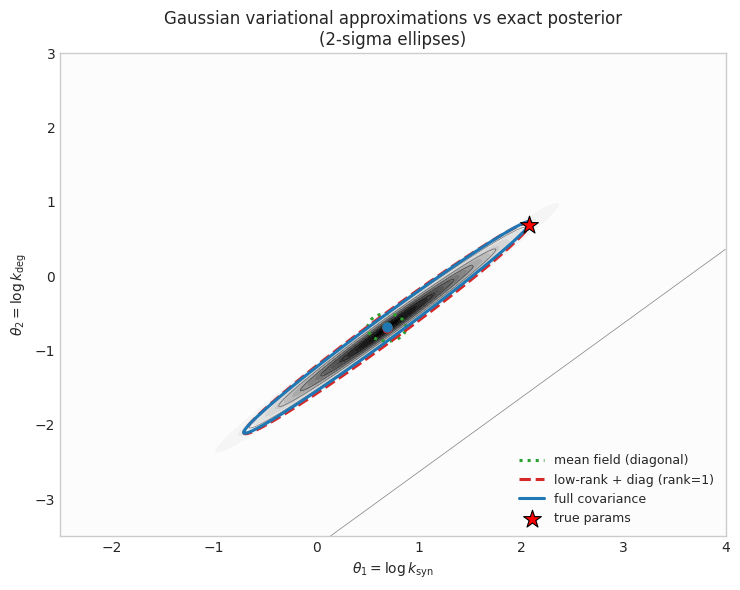

In [9]:
def gaussian_ellipse(mu, Sigma, n_std=2.0, n_pts=200):
    """Return points on the n_std-ellipse of N(mu, Sigma)."""
    L = np.linalg.cholesky(Sigma + 1e-8 * np.eye(len(mu)))
    t = np.linspace(0, 2*np.pi, n_pts)
    circle = n_std * np.vstack([np.cos(t), np.sin(t)])
    pts = mu[:, None] + L @ circle
    return pts[0], pts[1]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=6, colors='black', linewidths=0.5, alpha=0.5)

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'mean field (diagonal)'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'low-rank + diag (rank=1)'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'full covariance'),
]:
    xs, ys = gaussian_ellipse(q_mu, q_Sigma, n_std=2.0)
    ax.plot(xs, ys, color=color, linestyle=style, linewidth=2.2, label=label)
    ax.scatter([q_mu[0]], [q_mu[1]], color=color, s=40, zorder=4)

ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*',
           s=180, edgecolor='black', linewidth=0.8, zorder=5, label='true params')
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title('Gaussian variational approximations vs exact posterior\n(2-sigma ellipses)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 8: Quantitative Comparison

We compare each variational family on three criteria:
1. **Mean recovery** — distance from $\mathbb{E}_q[\boldsymbol{\theta}]$ to the exact posterior mean.
2. **Correlation recovery** — does the implied correlation match the exact $\rho \approx 1$?
3. **Final ELBO** — higher is better (closer to $\log p(\mathbf{y})$).

And we report the **marginal** posterior on the well-identified direction $\theta_1 - \theta_2$, which all three methods should get right because the data strongly constrains it.

In [10]:
# Posterior variance of the well-identified contrast theta1 - theta2 under each q.
def contrast_stats(mu, Sigma):
    v = np.array([1.0, -1.0])
    return v @ mu, np.sqrt(v @ Sigma @ v)

rows = [
    ("exact",         np.array([mu1_exact, mu2_exact]),
        np.array([[var1_exact, cov_exact], [cov_exact, var2_exact]]),  None),
    ("mean field",    mu_diag, Sigma_diag, trace_diag[-50:]),
    ("low-rank+diag", mu_lr,   Sigma_lr,   trace_lr[-50:]),
    ("full cov",      mu_full, Sigma_full, trace_full[-50:]),
]

print(f"{'method':<14} | {'E[t1]':>7} {'E[t2]':>7} | {'sd(t1)':>7} {'sd(t2)':>7} | {'corr':>6} | {'E[t1-t2]':>9} {'sd(t1-t2)':>10} | {'ELBO':>8}")
print("-" * 100)
for name, mu, Sigma, trace in rows:
    c, sdc = contrast_stats(mu, Sigma)
    corr = Sigma[0, 1] / np.sqrt(Sigma[0, 0] * Sigma[1, 1])
    elbo = f"{np.mean(trace):.3f}" if trace is not None else "-"
    print(f"{name:<14} | {mu[0]:>7.3f} {mu[1]:>7.3f} | "
          f"{np.sqrt(Sigma[0,0]):>7.3f} {np.sqrt(Sigma[1,1]):>7.3f} | "
          f"{corr:>6.3f} | {c:>9.3f} {sdc:>10.4f} | {elbo:>8}")

method         |   E[t1]   E[t2] |  sd(t1)  sd(t2) |   corr |  E[t1-t2]  sd(t1-t2) |     ELBO
----------------------------------------------------------------------------------------------------
exact          |   0.692  -0.692 |   0.708   0.708 |  0.992 |     1.385     0.0912 |        -
mean field     |   0.691  -0.691 |   0.093   0.093 |  0.000 |     1.381     0.1316 |   44.273
low-rank+diag  |   0.695  -0.697 |   0.700   0.712 |  0.989 |     1.393     0.1070 |   46.323
full cov       |   0.694  -0.688 |   0.701   0.713 |  0.991 |     1.382     0.0934 |   46.352


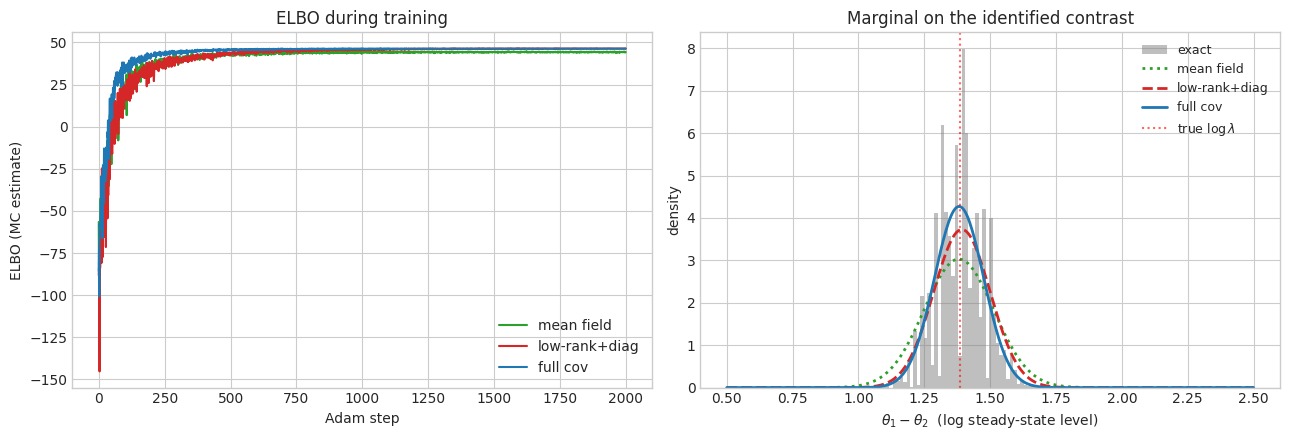

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ELBO traces
ax = axes[0]
ax.plot(trace_diag, label='mean field', color='#2ca02c')
ax.plot(trace_lr,   label='low-rank+diag', color='#d62728')
ax.plot(trace_full, label='full cov',  color='#1f77b4')
ax.set_xlabel('Adam step')
ax.set_ylabel('ELBO (MC estimate)')
ax.set_title('ELBO during training')
ax.legend()

# Right: Marginal on theta1 - theta2 (the well-identified contrast)
ax = axes[1]
diff_grid = np.linspace(0.5, 2.5, 400)
samples_idx = np.random.choice(post.size, size=80000, p=(post/post.sum()).ravel())
ii, jj = np.unravel_index(samples_idx, post.shape)
diff_samples_exact = T1[ii, jj] - T2[ii, jj]
ax.hist(diff_samples_exact, bins=60, density=True, color='gray', alpha=0.5,
        label='exact')

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'mean field'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'low-rank+diag'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'full cov'),
]:
    m, s = contrast_stats(q_mu, q_Sigma)
    pdf = np.exp(-0.5 * ((diff_grid - m) / s) ** 2) / (s * np.sqrt(2*np.pi))
    ax.plot(diff_grid, pdf, color=color, linestyle=style, linewidth=2, label=label)

ax.axvline(np.log(lambda_true), color='red', linestyle=':', alpha=0.6,
           label=r'true $\log \lambda$')
ax.set_xlabel(r'$\theta_1 - \theta_2$  (log steady-state level)')
ax.set_ylabel('density')
ax.set_title('Marginal on the identified contrast')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 9: Why Mean-Field is Over-Confident

$D_{\mathrm{KL}}(q \| p)$ is **mode-seeking**: it penalizes putting mass where $p$ is zero, so it shrinks $q$ to fit *inside* the high-probability region of $p$. For a diagonal-Gaussian $q$ approximating a tilted posterior, the only way to fit *inside* the diagonal ridge is to **shrink to a point near its center** — losing variance in both directions.

The full-covariance and low-rank+diag families instead align their major axis with the ridge, recovering the right variance in the well-identified direction (small variance along $\theta_1 - \theta_2$) and in the unidentified direction (large variance along $\theta_1 + \theta_2$, set by the prior).

This is exactly the lesson of **Figure 10.2** in PML-2: in high-dim posteriors with structure, even cheap rank-1 corrections are worth a lot.

## Summary

### What we built
We posed a Bayesian inference problem with a structured 2D posterior — joint inference of mRNA synthesis and degradation rates from steady-state RNA-seq counts — and fit it three ways using **reparameterized variational inference** in JAX:

| Family | Parameters | Captures correlation? | Practical use |
|---|---|---|---|
| Diagonal (mean field) | $2d$ | No | Default for VAEs, fast, often over-confident |
| Full (Cholesky) | $d(d+3)/2$ | Yes | Best fit, but $O(d^2)$ scaling |
| Low-rank + diag | $(r{+}2)d$ | Yes, the dominant $r$ directions | Excellent compromise in high dim (Eq. 10.57) |

### Key takeaways from PML-2 §10.2
1. **Reparameterization** turns an expectation under $q_{\boldsymbol{\psi}}$ into one under a fixed noise distribution, letting gradients flow through samples (Eq. 10.36–10.40).
2. The **diagonal Gaussian** is the easiest reparameterization (Eq. 10.44) but cannot capture posterior correlation — a well-known mode-seeking failure of $D_{\mathrm{KL}}(q \| p)$.
3. The **full Cholesky** parameterization captures all correlations but costs $O(d^2)$ parameters and decomposition.
4. The **low-rank + diagonal** factorization (VAFC, Eq. 10.57) costs only $O(d r)$ extra parameters yet recovers the dominant correlation direction — often nearly as good as full covariance.
5. Everything composes with **SVI** (minibatching, Section 10.1.4) and **amortization** (inference networks, Section 10.1.5), so the same gradient estimator scales to large datasets and neural-network posteriors.

### JAX-specific notes
- Variational parameters are `NamedTuple` pytrees; `optax` and `jax.grad` traverse them automatically — no `nn.Module` machinery required.
- `train_vi` JITs the gradient step once per family, then loops in Python so we can log ELBOs as we go. If you want maximum throughput, replace the Python loop with `jax.lax.scan` over `(key, opt_state, params)`.
- PRNG state is **explicit**: we split `key` at every step, so re-running the notebook produces deterministic results without a global seed.
- The low-rank log-density uses the Woodbury identity + matrix-determinant lemma so the cost stays $O(d r^2)$ even in high dimensions; for $d{=}2$, $r{=}1$ the numbers match the closed form exactly.